In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("bank[1].csv")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (11162, 17)


In [5]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [8]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
print(df["deposit"].value_counts())

deposit
no     5873
yes    5289
Name: count, dtype: int64


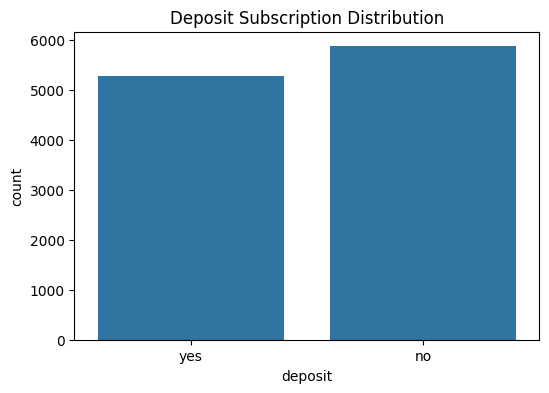

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="deposit", data=df)

plt.title("Deposit Subscription Distribution")

plt.show()

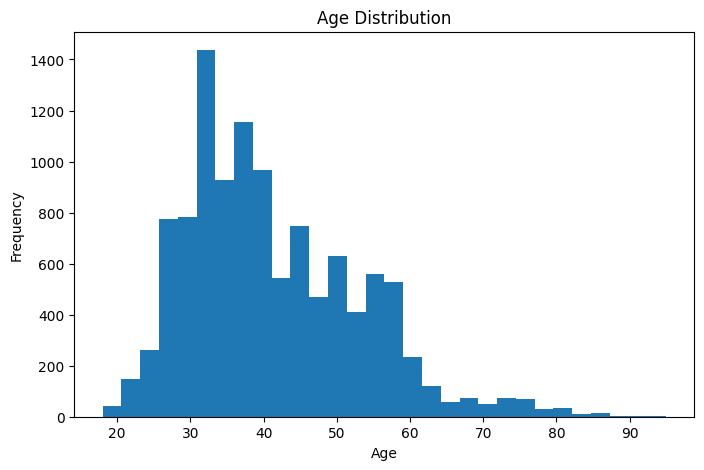

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=30)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

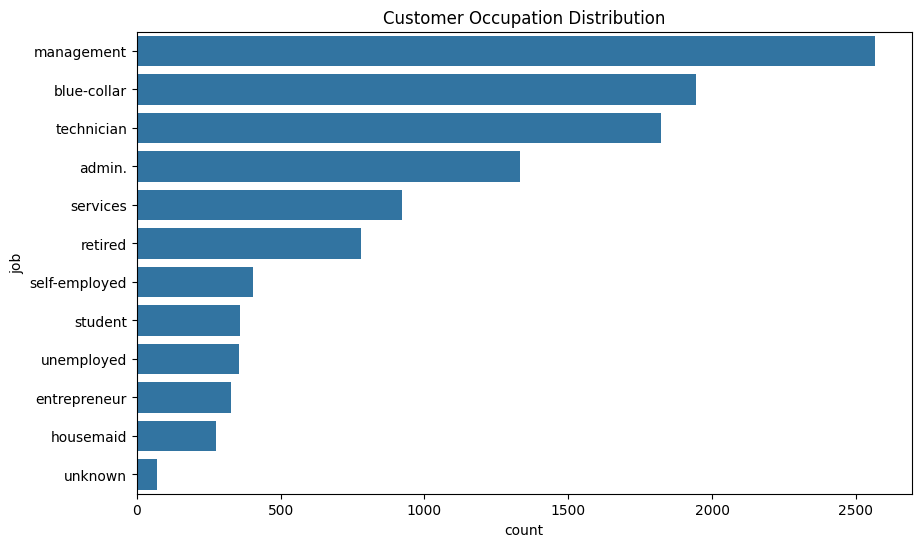

In [13]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="job",
    data=df,
    order=df["job"].value_counts().index
)

plt.title("Customer Occupation Distribution")

plt.show()

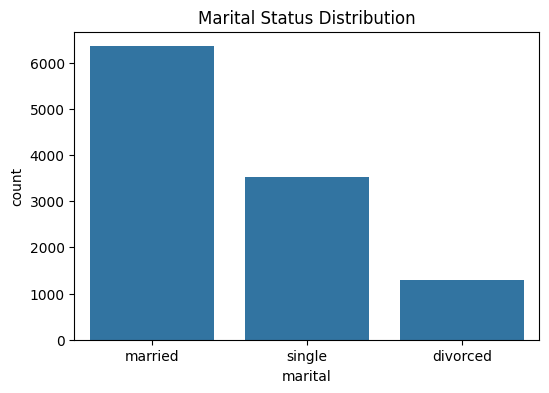

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="marital", data=df)

plt.title("Marital Status Distribution")

plt.show()

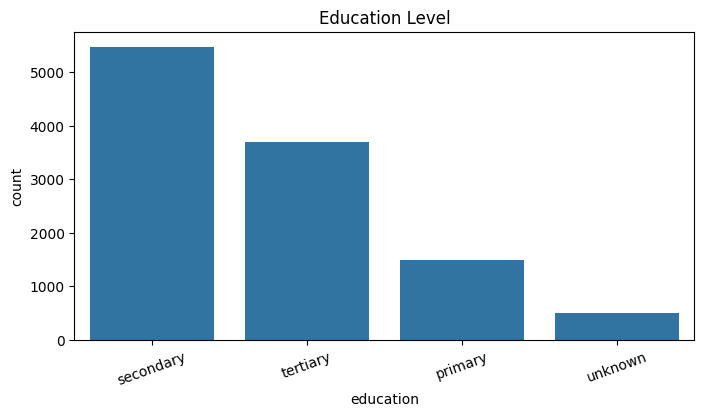

In [15]:
plt.figure(figsize=(8,4))

sns.countplot(
    x="education",
    data=df,
    order=df["education"].value_counts().index
)

plt.title("Education Level")

plt.xticks(rotation=20)

plt.show()

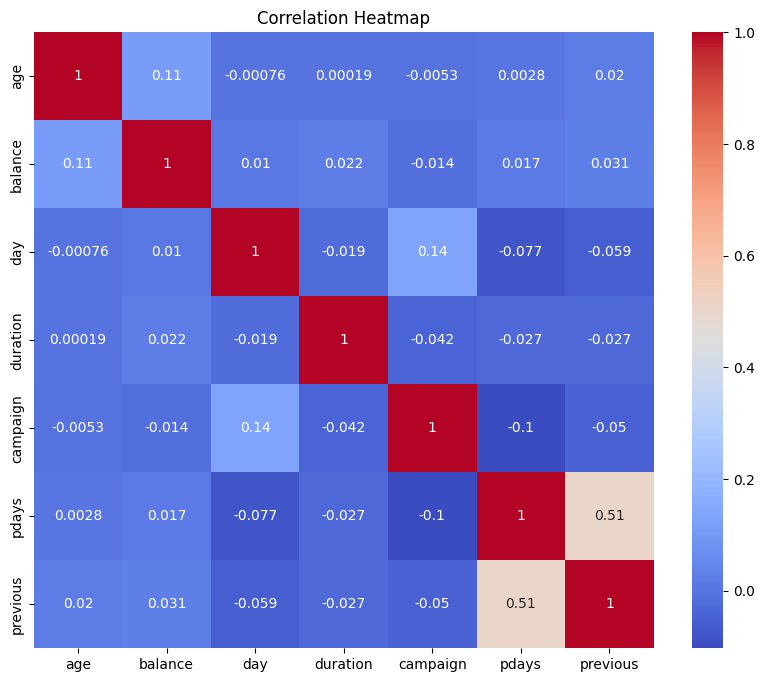

In [16]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [18]:
X = df.drop("deposit", axis=1)

y = df["deposit"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (8929, 16)
Testing Features  : (2233, 16)
Training Labels   : (8929,)
Testing Labels    : (2233,)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

In [23]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_accuracy)
print("Accuracy: {:.2f}%".format(log_accuracy * 100))

Logistic Regression Accuracy: 0.7899686520376176
Accuracy: 79.00%


In [24]:
df = pd.get_dummies(df, drop_first=True)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=3000, random_state=42)

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
df["deposit"] = df["deposit"].map({"no": 0, "yes": 1})

X = df.drop("deposit", axis=1)
y = df["deposit"]

### Correcting Data Preprocessing for Feature and Target Variables

To resolve the `NaN` values in the 'deposit' column (which is used as the target `y`), it's necessary to correctly re-process the data. The previous sequence of applying `LabelEncoder` and then `pd.get_dummies` to the same DataFrame, along with a misplaced `map` function, led to the 'deposit' column becoming corrupted with `NaN`s.

The following steps will:
1. Re-load the original DataFrame to ensure a clean slate.
2. Map the 'deposit' column to `0` and `1` directly.
3. Separate the features (`X`) and the target (`y`).
4. Apply one-hot encoding using `pd.get_dummies` to the remaining *categorical feature columns only* in `X`, preventing corruption of the target variable.

In [34]:
df_processed = pd.read_csv("bank[1].csv")

# Map the 'deposit' column to numerical values (0 and 1)
df_processed['deposit'] = df_processed['deposit'].map({'no': 0, 'yes': 1})

# Separate features (X) and target (y)
X = df_processed.drop('deposit', axis=1)
y = df_processed['deposit']

# Identify categorical columns for one-hot encoding (excluding 'deposit' which is already handled)
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to the identified categorical columns in X
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Display the head of the processed features and target to confirm
print("Processed X head:")
display(X.head())
print("\nProcessed y head:")
display(y.head())

Processed X head:


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True



Processed y head:


,deposit
0,1
1,1
2,1
3,1
4,1


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=3000, random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=3000, random_state=42)

In [38]:
y_pred = log_model.predict(X_test_scaled)

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 0.825794894760412
Accuracy: 82.58%


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Accuracy: {:.2f}%".format(rf_accuracy * 100))

Random Forest Accuracy: 0.8580385132109271
Accuracy: 85.80%


In [41]:
import pickle

pickle.dump(rf_model, open("bank_marketing_model.pkl", "wb"))

In [42]:
from google.colab import files

files.download("bank_marketing_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
plt.savefig("confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [46]:
from google.colab import files
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>